In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import warnings

In [2]:
warnings.filterwarnings("ignore")

## Best Practice
1. Preprocessing And Cleaning
2. Train Test Split
3. BOW, TFIDF, W2Vec
4. Train ML algoritm

In [3]:
df=pd.read_csv(r"E:\Works\NLP\Dataset\all_kindle_review .csv")
df.head(8)

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000
5,5,3744,B0021L9YDK,"[6, 6]",5,Aislinn is a little girl with big dreams. Afte...,"12 7, 2009",A3J5NN6MJK4M4A,"Aubrie A. Dionne ""Fantasy, Sci Fi Author""",A story of a little girl with big dreams.,1260144000
6,6,13641,B0038NN38W,"[1, 1]",2,This has the makings of a good story... unfort...,"08 18, 2011",A531QY5K7JVXI,Chicano,This story has potential but ultimately disapp...,1313625600
7,7,4448,B002AJ7X2C,"[1, 1]",4,I got this because I like collaborated short s...,"03 8, 2010",AN8ELR6AHMMQ,"Jessss ""I read to find stories that inspire m...",Good thriller,1268006400


In [4]:
df_new=df[["reviewText","rating"]]
df_new

,reviewText,rating
0,"Jace Rankin may be short, but he's nothing to ...",3
1,Great short read. I didn't want to put it dow...,5
2,I'll start by saying this is the first of four...,3
3,Aggie is Angela Lansbury who carries pocketboo...,3
4,I did not expect this type of book to be in li...,4
...,...,...
11995,Valentine cupid is a vampire- Jena and Ian ano...,4
11996,I have read all seven books in this series. Ap...,5
11997,This book really just wasn't my cuppa. The si...,3
11998,"tried to use it to charge my kindle, it didn't...",1


In [5]:
df_new.shape

(12000, 2)

In [6]:
df_new.isnull().sum()

reviewText    0
rating        0
dtype: int64

In [7]:
df_new["rating"].unique()

array([3, 5, 4, 2, 1], dtype=int64)

In [8]:
df_new["rating"].value_counts()

rating
5    3000
4    3000
3    2000
2    2000
1    2000
Name: count, dtype: int64

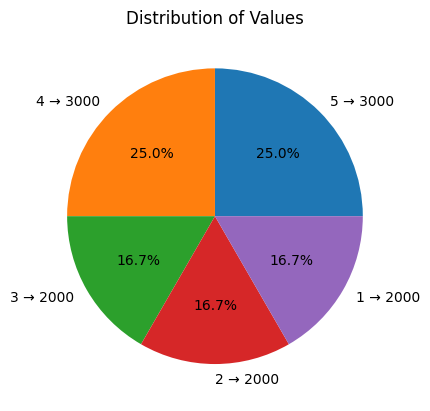

In [9]:
x = [3000, 3000, 2000, 2000, 2000]
y = [5, 4, 3, 2, 1]

plt.pie(
    x,
    labels=[f"{value} → {count}" for value, count in zip(y, x)],
    autopct='%1.1f%%'
)

plt.title("Distribution of Values")
plt.show()

In [10]:
#We have two Ways
#1
# df["rating"] = df["rating"].replace([1, 2], 0)
# df["rating"] = df["rating"].replace([3,4,5], 1)
#2
for i,j in enumerate(df_new["rating"]):
   if j < 3 :
       df_new["rating"][i] = 0
   else:
       df_new["rating"][i] = 1

In [11]:
df_new["rating"].values

array([1, 1, 1, ..., 1, 0, 1], dtype=int64)

In [12]:
df_new["rating"].value_counts()

rating
1    8000
0    4000
Name: count, dtype: int64

In [13]:
df_new["reviewText"]=df_new["reviewText"].str.lower()

In [14]:
import nltk
import gensim
import string
import re
from bs4 import BeautifulSoup
from gensim.models import Word2Vec
from nltk.stem import WordNetLemmatizer,SnowballStemmer
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords

In [15]:
#Cleaning Data
df_new['reviewText'] = df_new['reviewText'].apply(lambda x: re.sub('[^a-zA-Z0-9]+', ' ', str(x)))
df_new['reviewText'] = df_new['reviewText'].apply(lambda x: " ".join([y for y in x.split() if y.lower() not in stopwords.words("english")]))
df_new['reviewText'] = df_new['reviewText'].apply(lambda x: re.sub(r'(http|https|ftp|ssh)://([\w_-]+(?:(?:\.[\w_-]+)+))([\w.,@?^=%&:/~+#-]*[\w@?^+%&/~+#-])?', '', str(x)))
df_new['reviewText'] = df_new['reviewText'].apply(lambda x: BeautifulSoup(x, "lxml").get_text())
df_new['reviewText'] = df_new['reviewText'].apply(lambda x: " ".join(x.split()))

In [16]:
df_new["reviewText"].head(8)

0    jace rankin may short nothing mess man hauled ...
1    great short read want put read one sitting sex...
2    start saying first four books expecting 34 con...
3    aggie angela lansbury carries pocketbooks inst...
4    expect type book library pleased find price right
5    aislinn little girl big dreams death older bro...
6    makings good story unfortunately disappoints t...
7    got like collaborated short stories alot times...
Name: reviewText, dtype: object

In [17]:
lemmatizer=WordNetLemmatizer()

In [18]:
def lemmatize_text(text):
    words = word_tokenize(text)

    lemmatized_words = []

    for word in words:
        word = lemmatizer.lemmatize(word, pos="v")
        lemmatized_words.append(word)

    return " ".join(lemmatized_words)


df_new["reviewText"] = df_new["reviewText"].apply(lemmatize_text)

In [19]:
df_new["reviewText"]

0        jace rankin may short nothing mess man haul sa...
1        great short read want put read one sit sex sce...
2        start say first four book expect 34 conclude 3...
3        aggie angela lansbury carry pocketbooks instea...
4         expect type book library please find price right
                               ...                        
11995    valentine cupid vampire jena ian another vampi...
11996    read seven book series apocalyptic adventure o...
11997    book really cuppa situation man capture woman ...
11998    try use charge kindle even register charge com...
11999    take instruction look often hide world sexual ...
Name: reviewText, Length: 12000, dtype: object

In [20]:
words=[]
for i in range(len(df_new["reviewText"])):
    words.append(word_tokenize(df_new["reviewText"][i]))
words

[['jace',
  'rankin',
  'may',
  'short',
  'nothing',
  'mess',
  'man',
  'haul',
  'saloon',
  'undertaker',
  'know',
  'famous',
  'bounty',
  'hunter',
  'oregon',
  '1890s',
  'shoot',
  'man',
  'saloon',
  'finish',
  'years',
  'long',
  'quest',
  'avenge',
  'sister',
  'murder',
  'try',
  'figure',
  'next',
  'snotty',
  'nose',
  'farm',
  'boy',
  'rescue',
  'gang',
  'bully',
  'offer',
  'money',
  'kill',
  'man',
  'force',
  'ranch',
  'reluctantly',
  'agree',
  'bring',
  'man',
  'justice',
  'kill',
  'outright',
  'first',
  'need',
  'tell',
  'sister',
  'widower',
  'news',
  'kyla',
  'kyle',
  'springer',
  'bailey',
  'rid',
  'trail',
  'sleep',
  'grind',
  'past',
  'month',
  'try',
  'find',
  'jace',
  'want',
  'revenge',
  'man',
  'kill',
  'husband',
  'take',
  'ranch',
  'amongst',
  'crimes',
  'keen',
  'detour',
  'jace',
  'want',
  'take',
  'realize',
  'options',
  'hide',
  'behind',
  'boy',
  'persona',
  'best',
  'try',
  'keep'

In [21]:
w2vec=Word2Vec(words,epochs=25)

from tqdm import tqdm

def avg_word2vec(doc):
    vecs = [w2vec.wv[word] for word in doc if word in w2vec.wv.index_to_key]
    if len(vecs) > 0:
        return np.mean(vecs, axis=0)  # اینجا axis=0 مهمه!
    else:
        return np.zeros(w2vec.vector_size)
    
X=[]
for i in tqdm(range(len(words))):
    X.append(avg_word2vec(words[i]))

100%|██████████| 12000/12000 [00:06<00:00, 1877.56it/s]


In [22]:
w2vec.wv.similar_by_word("bad")

[('awful', 0.43215212225914),
 ('decent', 0.4153869152069092),
 ('poor', 0.41326579451560974),
 ('good', 0.41010600328445435),
 ('dumb', 0.3818390965461731),
 ('honestly', 0.3658590018749237),
 ('bug', 0.3623327314853668),
 ('tough', 0.3581019639968872),
 ('sick', 0.35373878479003906),
 ('alright', 0.3486596643924713)]

In [23]:
X_new=np.array(X)
X_new.shape

(12000, 100)

In [24]:
df_new2=pd.DataFrame(X_new)
df_new2

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.013944,0.058707,-0.076044,-0.067705,-0.155818,0.242728,0.072989,0.378757,0.209778,-0.260659,...,0.092592,0.227634,0.078946,0.035342,0.022540,0.170888,-0.152980,0.072763,0.154728,-0.001734
1,0.793793,-0.295817,-0.108007,0.341913,-0.399340,0.518419,-0.069944,-0.425310,0.502332,-0.748315,...,-0.373683,0.248279,-0.299392,0.559398,-0.587658,0.217639,-0.342567,0.670043,-0.373912,-0.382527
2,0.480574,-0.039004,-0.190252,0.118012,-0.242527,0.481540,0.195096,0.233502,0.205746,-0.602481,...,-0.127766,0.543652,0.185180,0.215454,-0.044594,0.076988,-0.519018,0.675730,0.012979,-0.265559
3,-0.062098,-0.033194,-0.440003,-0.308667,0.342585,0.435328,-0.117221,-0.233555,0.418986,-0.238814,...,-0.152620,0.832836,0.011858,0.082577,0.340593,0.149651,-0.597745,0.733569,0.045430,-0.303865
4,0.462879,0.706318,-0.497518,0.577403,0.022889,0.436569,0.028600,0.506455,-0.131588,-0.600645,...,0.061213,-0.129695,-0.726717,0.488123,0.348418,-0.224355,-0.448006,0.778362,-0.292359,0.330299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,-0.323482,-0.075349,-0.325095,-0.368776,-0.362658,-0.160017,-0.041074,0.182879,0.067478,-0.139124,...,-0.016309,0.255728,-0.394211,0.227936,-0.293886,0.718476,-0.294298,0.105907,0.589368,-0.698902
11996,0.264794,0.368443,0.048981,0.329136,-0.054945,0.264485,0.012796,-0.217775,0.434852,-0.515480,...,-0.320335,0.376626,-0.369998,0.241856,0.218863,0.143392,-0.517409,0.720624,-0.422370,-0.724886
11997,0.554880,-0.291879,-0.280018,-0.028205,0.083073,0.289568,-0.300838,0.048142,0.266901,-0.686092,...,-0.395639,0.545922,-0.290968,0.363712,-0.308986,0.210771,0.162183,0.286239,0.331495,-0.348154
11998,-0.193484,0.121703,-0.161123,0.464388,-0.206993,-0.119893,0.331143,0.248161,0.318648,-0.327581,...,0.403739,0.168772,0.083211,0.258484,0.047014,-0.376496,0.074940,0.476497,-0.318005,0.898811


In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df_new2,df_new["rating"],test_size=0.2)

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

svm score = 0.8308333333333333
              precision    recall  f1-score   support

           0       0.79      0.69      0.73       815
           1       0.85      0.90      0.88      1585

    accuracy                           0.83      2400
   macro avg       0.82      0.80      0.81      2400
weighted avg       0.83      0.83      0.83      2400



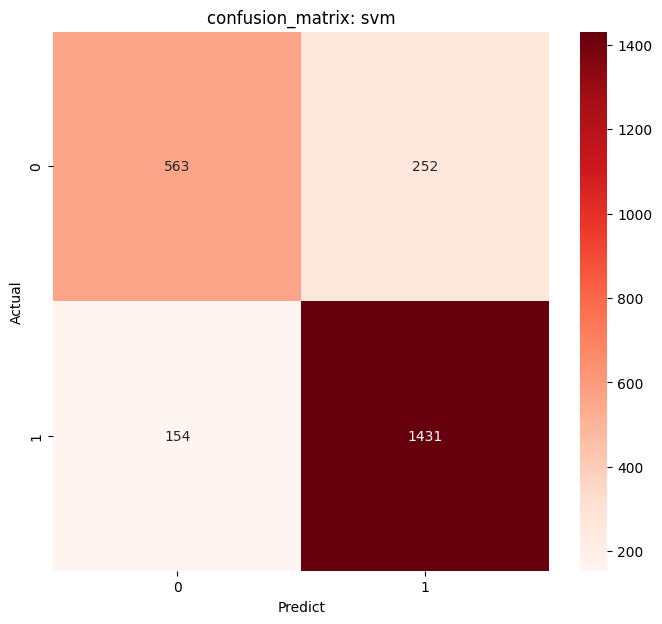

------------------------------------------------------------
Logistic Regression score = 0.8279166666666666
              precision    recall  f1-score   support

           0       0.78      0.69      0.73       815
           1       0.85      0.90      0.87      1585

    accuracy                           0.83      2400
   macro avg       0.81      0.79      0.80      2400
weighted avg       0.83      0.83      0.83      2400



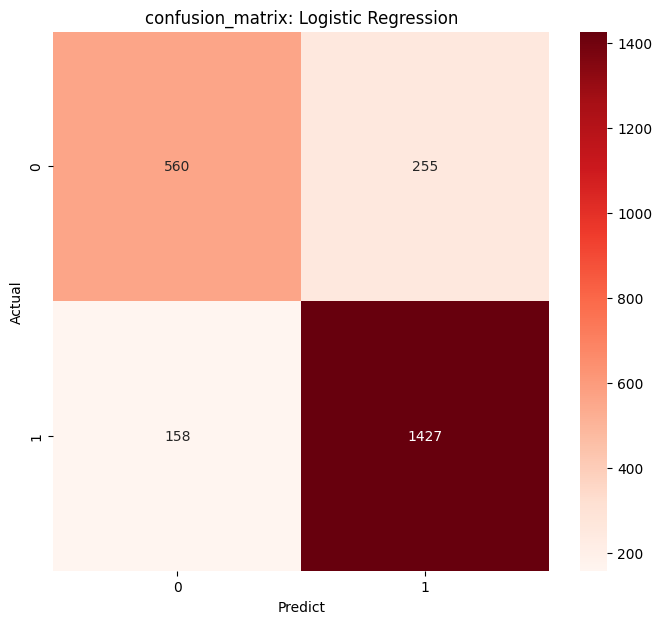

------------------------------------------------------------
RandomForestClassifier score = 0.8054166666666667
              precision    recall  f1-score   support

           0       0.78      0.60      0.68       815
           1       0.82      0.91      0.86      1585

    accuracy                           0.81      2400
   macro avg       0.80      0.76      0.77      2400
weighted avg       0.80      0.81      0.80      2400



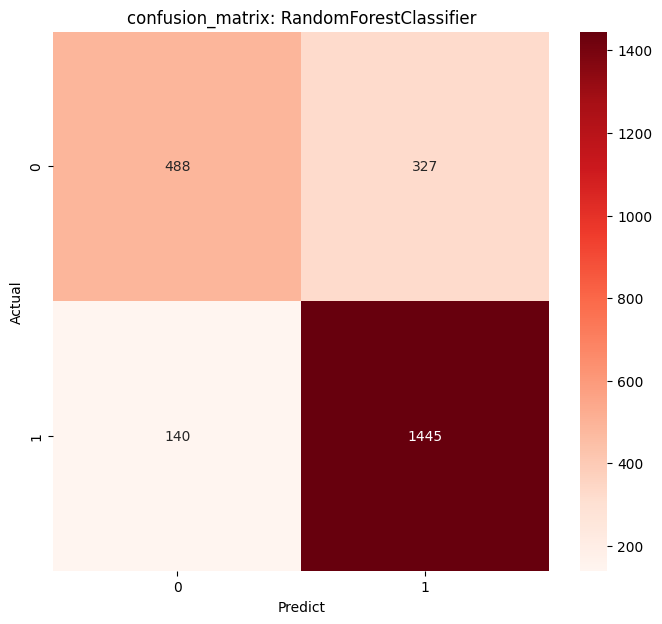

------------------------------------------------------------


In [27]:
models={"svm":LinearSVC(),"Logistic Regression":LogisticRegression(max_iter=1000),"RandomForestClassifier":RandomForestClassifier()}
for name,model in models.items():
    detect=model.fit(x_train,y_train)
    y_pred=detect.predict(x_test)
    cm=confusion_matrix(y_test,y_pred)
    print(f"{name} score = {accuracy_score(y_test,y_pred)}")
    print(classification_report(y_test,y_pred))
    plt.figure(figsize=(8,7))
    sb.heatmap(cm,annot=True,fmt="d",cmap="Reds",xticklabels=[0,1],yticklabels=[0,1])
    plt.title(f"confusion_matrix: {name}")
    plt.xlabel("Predict")
    plt.ylabel("Actual")
    plt.show()
    print("-"*60)